<a href="https://colab.research.google.com/github/PusunuruVenkat/ML_PRACTICAL/blob/main/exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost -q

In [2]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET_COL = "PlacementStatus"

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

os.listdir('/content/drive/MyDrive/colab')


['placement_dataset.csv',
 'placement_predict_50k.csv',
 'age_insurance.csv',
 'placement_predict_50k Dataset (1).csv',
 'simple_placement_dataset.csv',
 'placement_predict_50k_adjusted.csv']

In [5]:
import pandas as pd

file_path = "/content/drive/MyDrive/colab/simple_placement_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nDataset:")
display(df)

Dataset Shape: (50, 7)

Dataset:


,StudentID,CGPA,Internships,Projects,AptitudeTestScore,CommunicationSkill,Placed
0,1,6.87,2,2,57,8,0
1,2,9.75,1,2,95,1,1
2,3,8.66,1,0,71,6,1
3,4,7.99,3,2,74,8,1
4,5,5.78,1,4,91,5,1
5,6,5.78,1,1,86,4,0
6,7,5.29,1,1,35,2,0
7,8,9.33,3,0,57,6,0
8,9,8.01,1,3,57,6,1
9,10,8.54,2,0,73,1,0


In [6]:
print("Dataset Information:")
df.info()

print("\nClass Balance:")
print(df["Placed"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50 non-null     int64  
 1   CGPA                50 non-null     float64
 2   Internships         50 non-null     int64  
 3   Projects            50 non-null     int64  
 4   AptitudeTestScore   50 non-null     int64  
 5   CommunicationSkill  50 non-null     int64  
 6   Placed              50 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 2.9 KB

Class Balance:
Placed
0    25
1    25
Name: count, dtype: int64


In [7]:
TARGET = "Placed"
DROP_COLS = ["StudentID"]

feature_names = [c for c in df.columns if c not in [TARGET] + DROP_COLS]

X = df[feature_names]
y = df[TARGET]

print("Features:")
print(feature_names)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['CGPA', 'Internships', 'Projects', 'AptitudeTestScore', 'CommunicationSkill']

X shape: (50, 5)
y shape: (50,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40, 5)
Testing data: (10, 5)


In [9]:
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE
)

print("Random Forest model created.")

Random Forest model created.


In [10]:
rf.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [11]:
y_pred = rf.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 1 0 1 1 0 1 0 0]


In [12]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Accuracy: 0.8
Test Accuracy (%): 80.0


In [13]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.67      0.80         6

    accuracy                           0.80        10
   macro avg       0.83      0.83      0.80        10
weighted avg       0.87      0.80      0.80        10



In [14]:
print("OOB Score:", rf.oob_score_)
print("OOB Error:", 1 - rf.oob_score_)

OOB Score: 0.725
OOB Error: 0.275


In [15]:
print("Feature Importances:\n")

for name, importance in sorted(
    zip(feature_names, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"{name}: {importance:.4f}")

Feature Importances:

AptitudeTestScore: 0.4756
CGPA: 0.2715
CommunicationSkill: 0.1198
Internships: 0.0670
Projects: 0.0660


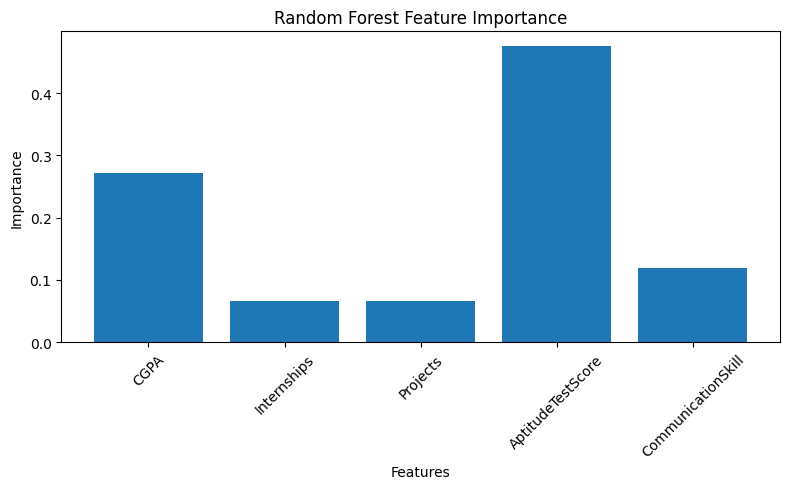

In [16]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(feature_names, importances)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:

print("========== EXPERIMENT 8 RESULTS ==========")
print("Algorithm: Random Forest")
print("Number of Trees:", rf.n_estimators)
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("OOB Score:", round(rf.oob_score_, 4))
print("OOB Error:", round(1 - rf.oob_score_, 4))
print("==========================================")

========== EXPERIMENT 8 RESULTS ==========
Algorithm: Random Forest
Number of Trees: 100
Test Accuracy: 80.0 %
OOB Score: 0.725
OOB Error: 0.275
